# Step1: Parse and resample the time series data

In [1]:
#importing necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

from prophet import Prophet

C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\Administrator\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv("D:\Data Science & Analytics Internship\Phase 2\Task 8 Energy Consumption Time Series Forecasting\household_power_consumption.csv", sep=",")
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [3]:
df.shape

(1048575, 9)

In [4]:
#checking null values
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Date                   1048575 non-null  str    
 1   Time                   1048575 non-null  str    
 2   Global_active_power    1048575 non-null  str    
 3   Global_reactive_power  1048575 non-null  str    
 4   Voltage                1048575 non-null  str    
 5   Global_intensity       1048575 non-null  str    
 6   Sub_metering_1         1048575 non-null  str    
 7   Sub_metering_2         1048575 non-null  str    
 8   Sub_metering_3         1044506 non-null  float64
dtypes: float64(1), str(8)
memory usage: 72.0 MB


In [5]:
# Convert 'Date' and 'Time' columns into a single datetime column
df['Datetime'] = pd.to_datetime(
    df['Date'] + ' ' + df['Time'],          # Combine date and time strings
    format='%d/%m/%Y %H:%M:%S',             # Specify the format 
    errors='coerce'                         # Invalid parsing will be set as NaT (Not a Time)
)

# Convert 'Global_active_power' column to numeric values
df['Global_active_power'] = pd.to_numeric(
    df['Global_active_power'],              # Try to convert values to numbers
    errors='coerce'                         # Invalid values will be set as NaN
)

# Keep only the relevant columns
df = df[['Datetime', 'Global_active_power']]

# Drop rows with missing values (NaT or NaN)
df.dropna(inplace=True)

# Set 'Datetime' column as the index of the DataFrame
df.set_index('Datetime', inplace=True)

df.head()

,Global_active_power
Datetime,
2006-12-16 17:24:00,4.216
2006-12-16 17:25:00,5.360
2006-12-16 17:26:00,5.374
2006-12-16 17:27:00,5.388
2006-12-16 17:28:00,3.666


In [6]:
# 'h' means 1-hour intervals 
# For each hour, calculate the mean of 'Global_active_power'

df_hourly = df.resample('h').mean()

# Step 2: Engineer time-based features (e.g., hour of day, weekday/weekend)

In [7]:
# Extract the hour (0–23) from the Datetime index
df_hourly['hour'] = df_hourly.index.hour

# Extract the day of the week (0 = Monday, 6 = Sunday)
df_hourly['dayofweek'] = df_hourly.index.dayofweek

# Create a new column 'is_weekend'
# It checks if the dayofweek is Saturday (5) or Sunday (6)
# .isin([5,6]) returns True/False → .astype(int) converts to 1 (weekend) or 0 (weekday)
df_hourly['is_weekend'] = df_hourly['dayofweek'].isin([5,6]).astype(int)

# Step 3: Compare performance of ARIMA, Prophet, and XGBoost models

In [8]:
train_size = int(len(df_hourly) * 0.8)
train = df_hourly.iloc[:train_size]
test = df_hourly.iloc[train_size:]

In [9]:
#1. Arima Model

arima_model = ARIMA(train['Global_active_power'], order=(5,1,2))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=len(test))

C:\Users\Administrator\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [10]:
#2. Prophet Model 

prophet_df = df_hourly.reset_index()[['Datetime', 'Global_active_power']]
prophet_df.columns = ['ds', 'y']

train_size = int(len(prophet_df) * 0.8)
prophet_train = prophet_df.iloc[:train_size]
prophet_test = prophet_df.iloc[train_size:]

model = Prophet()
model.fit(prophet_train)

future = model.make_future_dataframe(periods=len(prophet_test), freq='h')
forecast = model.predict(future)

prophet_pred = forecast['yhat'].iloc[train_size:]

14:06:19 - cmdstanpy - INFO - Chain [1] start processing
14:06:22 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
#3. Xgboost model

features = ['hour', 'dayofweek', 'is_weekend']

df_ml = df_hourly.copy()
df_ml = df_ml.dropna()

X = df_ml[features]
y = df_ml['Global_active_power']

In [12]:
train_size = int(len(X) * 0.8)

X_train, X_test = X.iloc[:train_size], X.iloc[train_size:]
y_train, y_test = y.iloc[:train_size], y.iloc[train_size:]

In [13]:
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    objective='reg:squarederror'
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

In [14]:
# Evaluation of models

def evaluate(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    print(f"{model_name} → MAE: {mae:.3f}, RMSE: {rmse:.3f}")

evaluate(test['Global_active_power'], arima_forecast, "ARIMA")
evaluate(prophet_test['y'], prophet_pred, "Prophet")
evaluate(y_test, xgb_pred, "XGBoost")

ARIMA → MAE: 0.683, RMSE: 0.907
Prophet → MAE: 0.707, RMSE: 0.942
XGBoost → MAE: 0.620, RMSE: 0.823


# Step 4: Plot actual vs. forecasted energy usage for visualization

ValueError: x and y must have same first dimension, but have shapes (3496,) and (3483,)

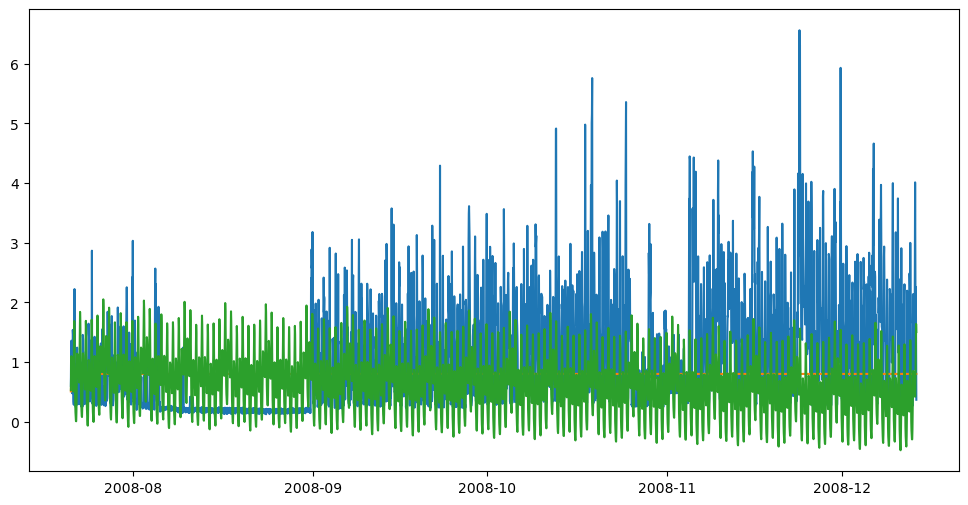

In [15]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test['Global_active_power'], label='Actual')
plt.plot(test.index, arima_forecast, label='ARIMA')
plt.plot(test.index, prophet_pred.values, label='Prophet')
plt.plot(test.index, xgb_pred, label='XGBoost')
plt.legend()
plt.title("Energy Consumption Forecast Comparison")
plt.xlabel("Time")
plt.ylabel("Global Active Power")
plt.show()